In [93]:
#!pip install catboost scikit-learn pandas numpy joblib
#or with conda for catboost:
#conda install -c conda-forge catboost
#!pip install spacy

In [197]:
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import shap

from datetime import datetime
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
#catboost
from catboost import Pool
from catboost import CatBoostClassifier
#scipy
from scipy.sparse import issparse, hstack

from plotly.subplots import make_subplots


In [198]:
#loading the dataset
df = pd.read_csv(r"C:\Users\VARSHA\Downloads\DMML\project dmml\MC_Fake_dataset.csv")

In [199]:
df.head() #first few rows to check column names

,news_id,title,url,publish_date,source,text,labels,n_tweets,n_retweets,n_replies,n_users,tweet_ids,retweet_ids,reply_ids,user_ids,retweet_relations,reply_relations,data_name
0,Claim-JuneFC18,WHO said artemisia plant cures Covid-19.,NaN,2020-05-05,NaN,"«Il n’y a rien de nouveau, juste un effet gros...",1,1,8,43,43,1258265925658259458,"1258266492573044736,1258268929732104192,125828...","1258265928321699840,1258266668821872640,125826...","1096021910972977152,529538368,1258273607278624...",1258266492573044736-1258265925658259458-722618...,1258265928321699840-1258265925658259458-284967...,FakeCovidClaimFiltered
1,Claim-JuneFC41,“There was no real scientific basis for belie...,NaN,2020-05-04,NaN,"More Info, Fox News host Laura Ingraham speaks...",1,4,1,5148,3759,"1258329173141094401,1258514570945032192,128065...",1280680704116998144,"1280654816352624640,1280655159643660288,128065...","795107478157586432,866860504203046914,14261352...",NaN,1280654816352624640-1280654150955565056-133715...,FakeCovidClaimFiltered
2,Claim-JuneFC46,Joe Biden has “written a letter of apology” fo...,NaN,2020-05-03,NaN,"More Info, President Donald Trump speaks durin...",1,3,57,12,66,"1257361723872419841,1257633359351746561,125770...","1257361909428486145,1257362106883719171,125736...","1257362357795336193,1257362452246859778,125736...","826295010542772224,1211394495654162433,1080666...",1257361909428486145-1257361723872419841-794136...,1257362357795336193-1257361723872419841-832319...,FakeCovidClaimFiltered
3,Claim-JuneFC47,Did US House Speaker Pelosi 'Hold Back' Corona...,NaN,2020-03-11,NaN,"Hirsch, Laura and Kevin Breuninger.\xa0“Trump ...",1,10,2,0,12,"1237873947925856256,1238121200989151232,123823...","1240854409371926528,1240858669895438336",NaN,"1137466967269498880,18526305,72153358413834240...",1240854409371926528-1240661167724470273-113746...,NaN,FakeCovidClaimFiltered
4,Claim-JuneFC55,"“A few hours ago, China officially announced ...",NaN,2020-04-03,NaN,Tanto en Facebook como en Twitter se ha vuelto...,1,5,15,13,23,"1239254388377563143,1239378517697212422,124000...","1239258123950600192,1239379736222150662,123956...","1240026703860314112,1240060236838379521,124006...","1069892389425180672,828922917174071297,1079227...",1239258123950600192-1239254388377563143-633421...,1240026703860314112-1239378517697212422-664343...,FakeCovidClaimFiltered


In [200]:
print(df.info()) #info about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28335 entries, 0 to 28334
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   news_id            28335 non-null  object
 1   title              28335 non-null  object
 2   url                21674 non-null  object
 3   publish_date       17896 non-null  object
 4   source             13942 non-null  object
 5   text               28133 non-null  object
 6   labels             28335 non-null  int64 
 7   n_tweets           28335 non-null  int64 
 8   n_retweets         28335 non-null  int64 
 9   n_replies          28335 non-null  int64 
 10  n_users            28335 non-null  int64 
 11  tweet_ids          28328 non-null  object
 12  retweet_ids        24905 non-null  object
 13  reply_ids          19132 non-null  object
 14  user_ids           28335 non-null  object
 15  retweet_relations  24816 non-null  object
 16  reply_relations    19073 non-null  objec

In [201]:
#parse publish_date amd extract simple time features for modelling
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['publish_dayofweek'] = df['publish_date'].dt.dayofweek.fillna(-1).astype(int)
df['publish_hour'] = df['publish_date'].dt.hour.fillna(-1).astype(int)
df['publish_month'] = df['publish_date'].dt.month.fillna(-1).astype(int)
df['is_weekend'] = df['publish_dayofweek'].isin([5,6]).astype(int)

In [202]:
#remove noise and create a clean full-text column
#text cleaning 
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'http\S+|www\.\S+', ' ', s) #remove urls
    s = re.sub(r'<.*?>', ' ', s) #remove html
    s = re.sub(r'\S+@\S+', ' ', s) #remove emails
    s = re.sub(r'[^a-z0-9\s]', ' ', s) #keep this symbol only 
    s = re.sub(r'\s+', ' ', s).strip()
    return s
    
df['text_clean'] = df['text'].fillna('').apply(clean_text)
df['title_clean'] = df['title'].fillna('').apply(clean_text)
df['full_text'] = (df['title_clean'] + ' . ' + df['text_clean']).str.strip()

In [203]:
#fill missing values and create a simple text and engagement features
num_cols = ['n_tweets','n_retweets','n_replies','n_users'] #activity recieved on social media
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df[c] = df[c].fillna(df[c].median())

df['text_length'] = df['text_clean'].str.len()
df['word_count'] = df['text_clean'].str.split().str.len().fillna(0).astype(int)
df['retweet_ratio'] = df['n_retweets'] / (df['n_tweets'].replace(0,1))

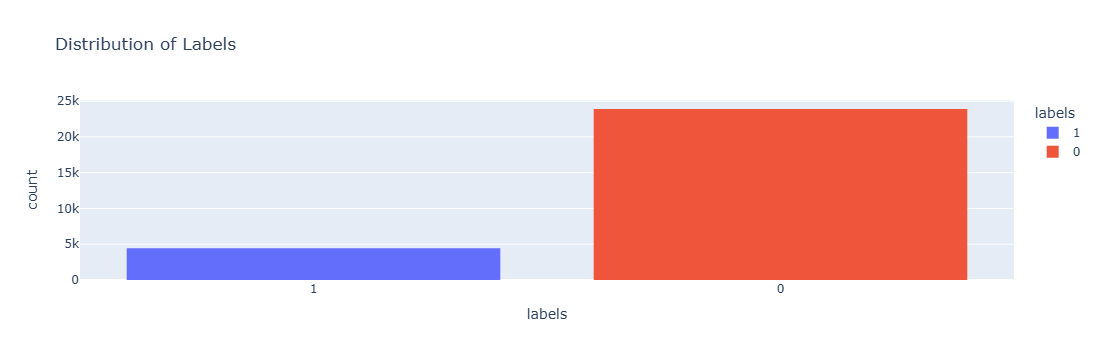

In [261]:
#Histogram for distributiuon of Labels 
px.histogram(df, x='labels', title='Distribution of Labels', color='labels') #check if dataset is balanced or if one label appears much more than other

In [237]:
#Heatmap - Source vs Label 
heat = df.pivot_table(index='source', columns='labels', values='news_id', aggfunc='count') #check if some sources are more fake/real compared to other
px.imshow(heat, title='Source vs Labels Heatmap') 

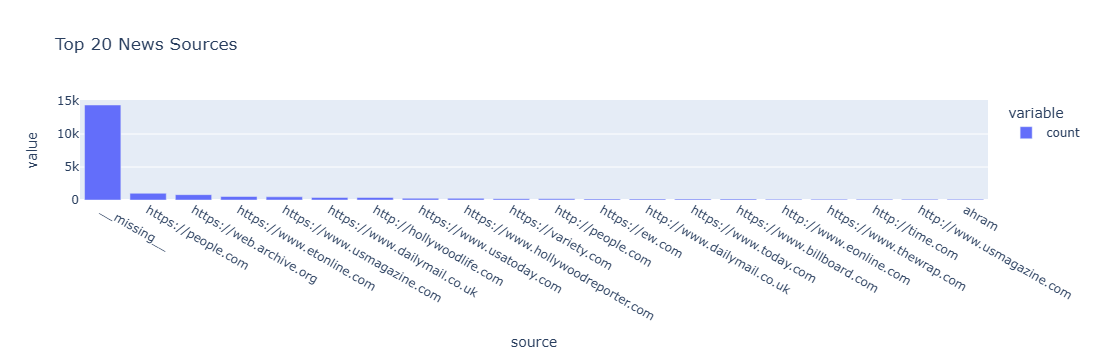

In [264]:
#Bar Chart - Top 20 Most Common Sources
src = df['source'].value_counts().head(20) #sources appear most frequently
px.bar(src, title='Top 20 News Sources')

Columns: ['news_id', 'title', 'url', 'publish_date', 'source', 'text', 'labels', 'n_tweets', 'n_retweets', 'n_replies', 'n_users', 'tweet_ids', 'retweet_ids', 'reply_ids', 'user_ids', 'retweet_relations', 'reply_relations', 'data_name', 'publish_dayofweek', 'publish_hour', 'publish_month', 'is_weekend', 'text_clean', 'title_clean', 'full_text', 'text_length', 'word_count', 'retweet_ratio', 'label_enc']

Sample values (source, labels):


,source,labels
0,__missing__,1
1,__missing__,1
2,__missing__,1
3,__missing__,1
4,__missing__,1
5,__missing__,1
6,__missing__,1
7,__missing__,1



Counts / missingness:
0 missing sources
0 missing labels


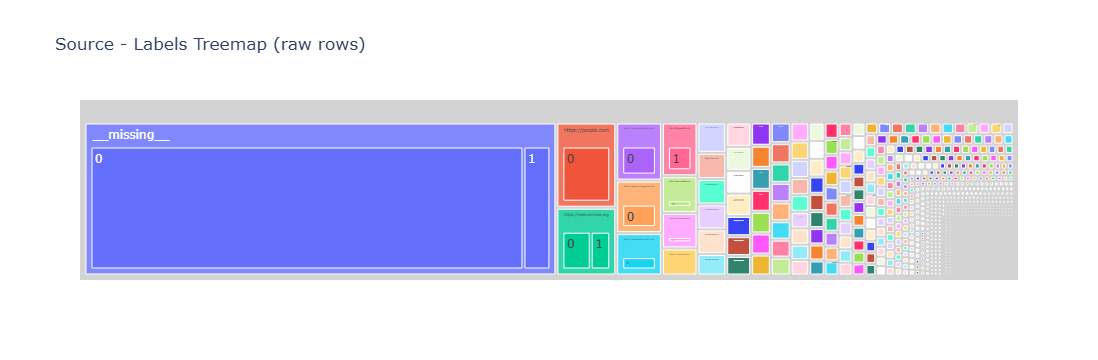

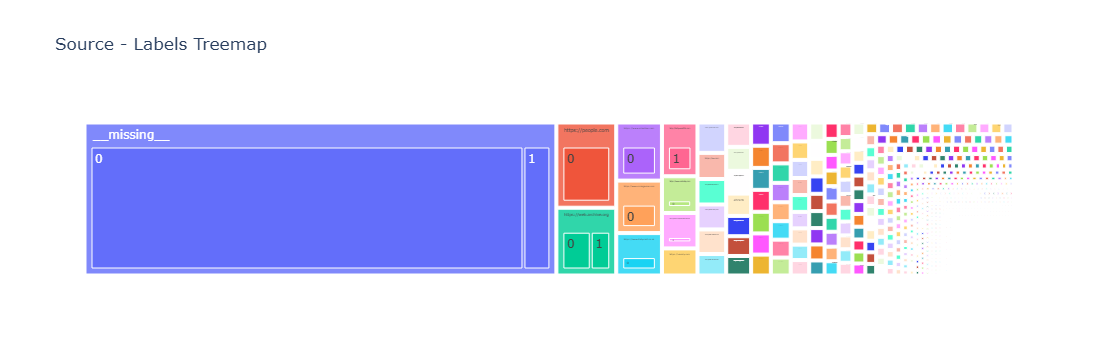

In [267]:
#Treemap for Category  
print("Columns:", df.columns.tolist())
print("\nSample values (source, labels):")
display(df[['source','labels']].head(8))

print("\nCounts / missingness:") #check missing values are present in each column
print(df['source'].isna().sum(), "missing sources")
print(df['labels'].isna().sum(), "missing labels")

# Making sure both columns have no missing values and stored as str
df['source'] = df['source'].fillna("__missing__").astype(str)
df['labels'] = df['labels'].fillna("__missing__").astype(str)

fig = px.treemap(df, path=['source','labels'],
                 title='Source - Labels Treemap (raw rows)')
fig.update_traces(root_color="lightgrey")
fig.show()

px.treemap(df, path=['source','labels'], title='Source - Labels Treemap')

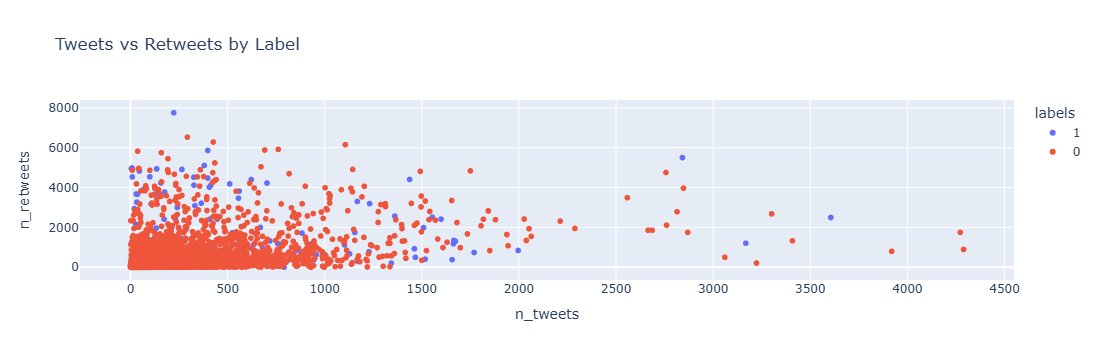

In [268]:
#Scatter Plot- no. of Tweets vs Rno. of etweets
px.scatter(df, x='n_tweets', y='n_retweets', 
           color='labels', title='Tweets vs Retweets by Label') #check fake and real labels show any different patterns

Numeric features used for correlation: ['n_tweets', 'n_retweets', 'n_replies', 'n_users', 'publish_dayofweek', 'publish_hour', 'publish_month', 'is_weekend', 'text_length', 'word_count', 'retweet_ratio', 'label_enc']


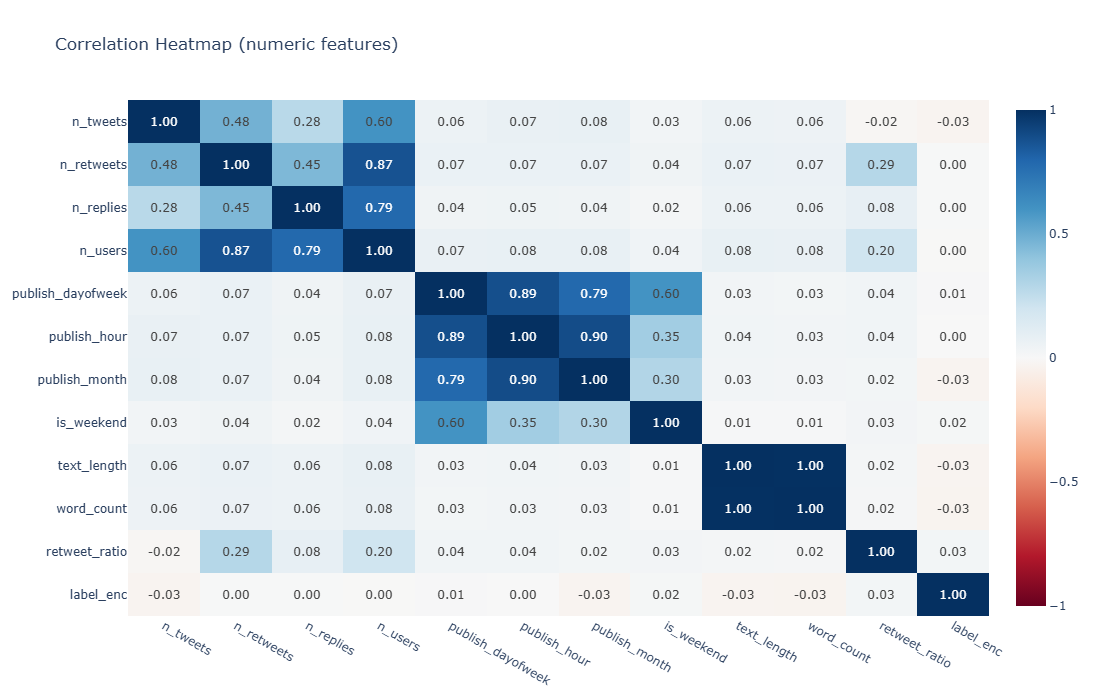

In [270]:
#Correlation Heatmap -numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
#check list is empty or not
if not numeric_features:
    raise ValueError("No numeric columns detected in df. Check df or define numeric_features manually.")
print("Numeric features used for correlation:", numeric_features)

#checking all numeric columns are actually numeric 
for c in numeric_features:
    df[c] = pd.to_numeric(df[c], errors='coerce')

#copy of only numeric data for correlation
corr_df = df[numeric_features].copy()

#Removing columns which have same value 
const_cols = corr_df.columns[corr_df.nunique(dropna=True) <= 1].tolist()
if const_cols:
    print("Dropping constant columns (no variance):", const_cols)
    corr_df = corr_df.drop(columns=const_cols)

#Compute correlation matrix
corr = corr_df.corr()

#Plot interactive heatmap with Plotly
fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    color_continuous_scale='RdBu', #Blue- negative correlation and red- positive
    zmin=-1, zmax=1,
    title='Correlation Heatmap (numeric features)'
)
fig.update_layout(width=900, height=700) #adjusting the size of the heatmap
fig.update_xaxes(side="bottom")
fig.show()

numeric_features = ['n_tweets','n_retweets','n_replies','n_users','text_length','word_count','publish_hour','publish_dayofweek']

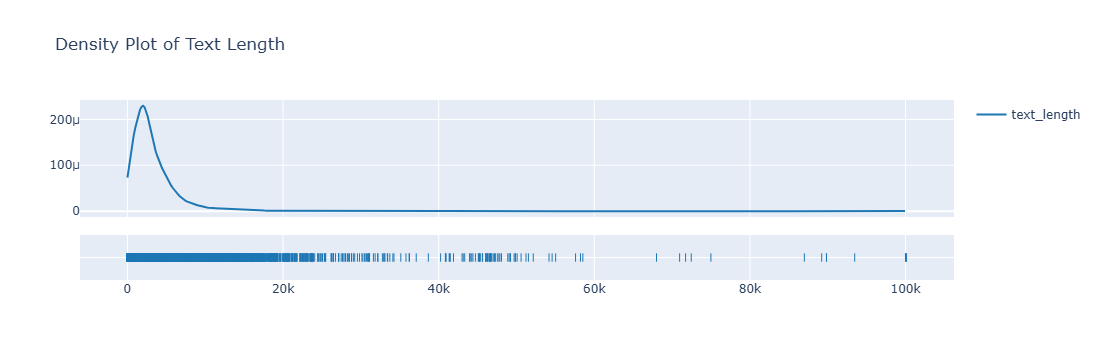

In [277]:
#KDE Plot 
df.columns #check column names to confirm text
# Create text feature columns
df['text'] = df['text'].astype(str)   # ensure string
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# KDE Plot of Text Length
fig = ff.create_distplot([df['text_length']], ['text_length'], show_hist=False)
fig.update_layout(title='Density Plot of Text Length')
fig.show()

In [205]:
#label encoding 
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['labels'].astype(str)) #fit the encoder
#Takes the labels column (ex.fake/real)and converts it to a string, and encodes it as numbers (0, 1)

In [206]:
#test-train split
X = df.copy() 
y = df['label_enc'] #encoded labels
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42) #20% for testing for consistent results
print("Training size:", len(X_train))
print("Test size:", len(X_test))
print("Label distribution in train:\n", y_train.value_counts(normalize=True))
print("Label distribution in test:\n", y_test.value_counts(normalize=True))

Training size: 22668
Test size: 5667
Label distribution in train:
 label_enc
0    0.843347
1    0.156653
Name: proportion, dtype: float64
Label distribution in test:
 label_enc
0    0.843303
1    0.156697
Name: proportion, dtype: float64


In [207]:
#transforming columns and preprocessing- to numeric, categorical, and text features
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3) #TF-IDF for full_text column
numeric_features = ['n_tweets','n_retweets','n_replies','n_users','text_length','word_count','publish_hour','publish_dayofweek'] #feature groups
categorical_features = ['source','data_name']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('txt', tfidf, 'full_text') #convert text-to TF-IDF
    ],#creating the transformer
    remainder='drop' #drop which is not in used
)

In [208]:
#TF-IDF vectorizer for text - all feature types -numeric, categorical, text for model
tfidf = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2),
    min_df=3
)
categorical_features = ['source', 'data_name']   #passed directly to CatBoost

# Final preprocessor - OneHotEncoder
preproc_catboost = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), #scale numeric
        ('txt', tfidf, 'full_text'), #encode categories
        ('cat_passthru', 'passthrough', categorical_features)#convert text to TF-IDF
    ],
    remainder='drop',
    sparse_threshold=0.3 #manage TF-IDF features
) #converting the column into TF-IDF vector
print("STEP 4 preprocessor created successfully.")

STEP 4 preprocessor created successfully.


In [209]:
#Robust preprocessing for CatBoost Pool
#Quick diagnostics
text_feature = "full_text"
print("Checking missing values (train):") 
print(X_train[categorical_features + [text_feature]].isna().sum()) #check how many missing values

Checking missing values (train):
source       11470
data_name        0
full_text        0
dtype: int64


In [278]:
#Clean the text column
for c in categorical_features: #for each categorical column
    if c in X_train.columns:
        # Replace missing values with a special word and make everything a string
        X_train[c] = X_train[c].fillna("__missing__").astype(str)
        X_test[c]  = X_test[c].fillna("__missing__").astype(str)
    else:
        raise KeyError(f"Categorical column '{c}' not found in X_train/X_test") 

#clean text column and it is a string 
if text_feature in X_train.columns: # checking text column has no missing values and storing it as plain text
    X_train[text_feature] = X_train[text_feature].fillna("").astype(str)
    X_test[text_feature]  = X_test[text_feature].fillna("").astype(str) 
else:
    raise KeyError(f"Text column '{text_feature}' not found in X_train/X_test") #if the column is missing it will stop

In [279]:
#Clean and fill numeric columns - assign numeric columns and convert to numeric dtype
for n in numeric_features:
    if n in X_train.columns: #Convert values to numbers, it will turn errors into NaN
        X_train[n] = pd.to_numeric(X_train[n], errors="coerce")
        X_test[n]  = pd.to_numeric(X_test[n], errors="coerce")
        med = np.nanmedian(X_train[n]) #Find the middle value from the training data
        # if med is nan (all missing), fill with 0
        if np.isnan(med):
            med = 0
        #Fill missing numbers with the median
        X_train[n] = X_train[n].fillna(med)
        X_test[n]  = X_test[n].fillna(med)
    else:
        #if the numeric column doesn't exist
        print(f"Warning: numeric feature '{n}' not found — skipping imputation for it.")

In [280]:
#Final checks 
print("\nAfter filling:")
print(X_train[categorical_features + [text_feature]].isna().sum()) ##Show missing values again after cleaning
print("Any non-string in categorical columns (train)?") 
#Check few values to confirm everything is stored as strings
for c in categorical_features:
    sample_vals = X_train[c].dropna().head(5).tolist()
    print(f"  {c}: sample values -> {sample_vals}")


After filling:
source       0
data_name    0
full_text    0
dtype: int64
Any non-string in categorical columns (train)?
  source: sample values -> ['__missing__', '__missing__', '__missing__', 'http://www.lifeandstylemag.com', 'https://www.today.com']
  data_name: sample values -> ['RealHealth', 'RealSyria', 'RealHealth', 'gossipcop', 'gossipcop']


In [281]:
#create CatBoost Pool using column NAMES
#Collect all columns that will be used in training
train_data = X_train[categorical_features + numeric_features + [text_feature]].copy()
test_data  = X_test[categorical_features + numeric_features + [text_feature]].copy()

#Create CatBoost data containers and pass categorical feature names and text feature names
train_pool = Pool(data=train_data, label=y_train, 
                  cat_features=categorical_features, text_features=[text_feature])
test_pool  = Pool(data=test_data, label=y_test, 
                  cat_features=categorical_features, text_features=[text_feature])

print("\nPools created successfully. Pool sizes:", train_pool.shape, test_pool.shape)


Pools created successfully. Pool sizes: (22668, 11) (5667, 11)


In [282]:
#Build and train the CatBoost model
model = CatBoostClassifier(iterations=400, learning_rate=0.05, depth=6, random_seed=42, verbose=100)
model.fit(train_pool, eval_set=test_pool)

0:	learn: 0.6564981	test: 0.6568932	best: 0.6568932 (0)	total: 125ms	remaining: 50s
100:	learn: 0.1013928	test: 0.0907079	best: 0.0907079 (100)	total: 12.8s	remaining: 37.9s
200:	learn: 0.0873611	test: 0.0859758	best: 0.0859758 (200)	total: 24.5s	remaining: 24.3s
300:	learn: 0.0772038	test: 0.0838130	best: 0.0838121 (298)	total: 37s	remaining: 12.2s
399:	learn: 0.0686322	test: 0.0824575	best: 0.0824012 (397)	total: 49.8s	remaining: 0us

bestTest = 0.08240121233
bestIteration = 397

Shrink model to first 398 iterations.


In [285]:
#Make predictions and show results
y_pred = model.predict(test_pool) #Predict labels for test set
print("\nClassification report CatBoost:")
# print(classification_report(y_test, y_pred))
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T #create a structered library and convert the dictionary to dataframe


Classification report CatBoost:


,precision,recall,f1-score,support
0,0.966762,0.992049,0.979242,4779.000000
1,0.950197,0.816441,0.878256,888.000000
accuracy,0.964531,0.964531,0.964531,0.964531
macro avg,0.958479,0.904245,0.928749,5667.000000
weighted avg,0.964166,0.964531,0.963418,5667.000000


In [216]:
#build ColumnTransformer: TF-IDF, scaler (numeric) and one-hot (categorical)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)

preproc_rf = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), #scaling the numeric columns
        ('txt', tfidf, text_feature), #apply TF-IDF to the text
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # turn categories into vectors
    ],
    remainder='drop', # drop any other columns not listed in this
    sparse_threshold=0.3
)

In [217]:
#Fit-transform train and transform test
print("Fitting preprocessor (RF) on X_train ...")
X_train_rf = preproc_rf.fit_transform(X_train)
X_test_rf  = preproc_rf.transform(X_test) # Apply transformations to the test data
print("Transformed shapes -> train:", getattr(X_train_rf, "shape", None), " test:", getattr(X_test_rf, "shape", None)) #shapes of the transformed datasets

Fitting preprocessor (RF) on X_train ...
Transformed shapes -> train: (22668, 11233)  test: (5667, 11233)


In [256]:
# #Train RandomForest model
# rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42) #Create RandomForest model with 200 trees
# # print("Training RandomForest...")
# #Train RandomForest using the transformed training data
# rf.fit(X_train_rf, y_train)
# # print("RandomForest training done.")

In [284]:
#Evaluate model
y_pred_rf = rf.predict(X_test_rf) # Use trained model to predict labels
print("\nClassification report RandomForest:")
# print(classification_report(y_test, y_pred_rf))
pd.DataFrame(classification_report(y_test, y_pred_rf, output_dict=True)).T


Classification report RandomForest:


,precision,recall,f1-score,support
0,0.911669,0.995606,0.951790,4779.000000
1,0.953125,0.480856,0.639222,888.000000
accuracy,0.914946,0.914946,0.914946,0.914946
macro avg,0.932397,0.738231,0.795506,5667.000000
weighted avg,0.918165,0.914946,0.902812,5667.000000


In [220]:
#metrices comparison
def get_metrics(model_obj, X_transformed, y_true, is_catboost_pool=False):
    # For CatBoost Pool handling both cases.
    if is_catboost_pool:
        y_pred = model_obj.predict(X_transformed)
        try:
            y_proba = model_obj.predict_proba(X_transformed) #required for auc
        except Exception:
            y_proba = None
    else:
        y_pred = model_obj.predict(X_transformed)
        try:
            y_proba = model_obj.predict_proba(X_transformed)
        except Exception:
            y_proba = None
    #calculate classification metrices
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    #Prepare a variable for ROC-AUC
    auc = None
    if y_proba is not None:
        try: 
            if y_proba.shape[1] == 2: #For binary classification using the second column of probabilities
                auc = roc_auc_score(y_true, y_proba[:,1])
            else:
                auc = roc_auc_score(y_true, y_proba, multi_class="ovr") #For multi-class models using one-vs-rest AUC
        except Exception:
            auc = None

    return {"accuracy": acc, 
            "precision_macro": prec, 
            "recall_macro": rec, 
            "f1_macro": f1, 
            "roc_auc": auc, 
            "y_pred": y_pred, 
            "y_proba": y_proba
           } # Return all scores and predictions

In [221]:
#Compare CatBoost and RandomForest
cat_metrics = get_metrics(model, test_pool, y_test, is_catboost_pool=True) #CatBoost metrics 

rf_metrics = get_metrics(rf, X_test_rf, y_test, is_catboost_pool=False) #RandomForest metrics
#Create a comparison table and build DataFrame
df_compare = pd.DataFrame([
    {"model":"CatBoost (Pool)", 
     **{k:v for k,v in cat_metrics.items() if k in 
        ['accuracy','precision_macro','recall_macro','f1_macro','roc_auc']}},
    {"model":"RandomForest", 
     **{k:v for k,v in rf_metrics.items() if k in 
        ['accuracy','precision_macro','recall_macro','f1_macro','roc_auc']}},
])
print(df_compare) #print comparison table

             model  accuracy  precision_macro  recall_macro  f1_macro  \
0  CatBoost (Pool)  0.964531         0.958479      0.904245  0.928749   
1     RandomForest  0.914946         0.932397      0.738231  0.795506   

    roc_auc  
0  0.991627  
1  0.967862  


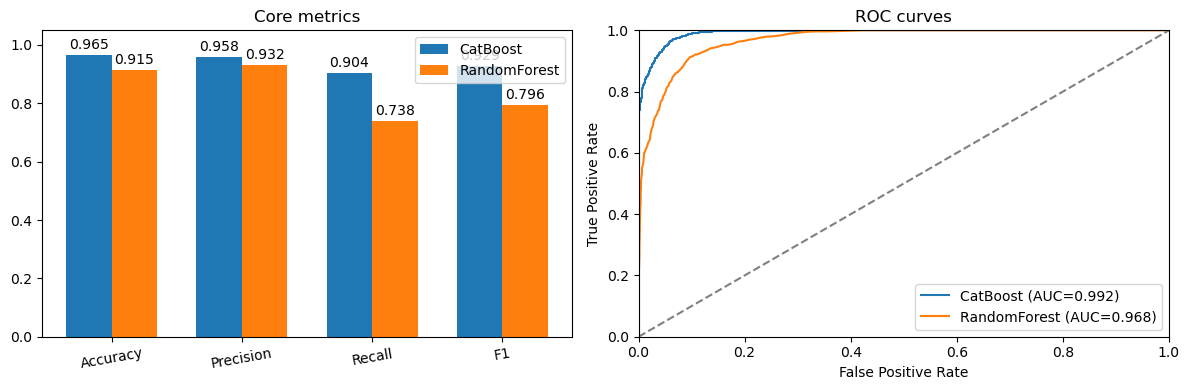

In [222]:
#from above comparison table generate charts
simple_compare_plots(cat_metrics, rf_metrics, y_test)
def simple_compare_plots(cat_metrics, rf_metrics, y_true):
    #Build a short table for the bar chart
    df = pd.DataFrame({
        "model": ["CatBoost", "RandomForest"],
        "accuracy": [cat_metrics["accuracy"], rf_metrics["accuracy"]],
        "precision": [cat_metrics["precision_macro"], rf_metrics["precision_macro"]],
        "recall": [cat_metrics["recall_macro"], rf_metrics["recall_macro"]],
        "f1": [cat_metrics["f1_macro"], rf_metrics["f1_macro"]],
    }).set_index("model")

    #Grouped bar chart -compact
    metrics = df.columns.tolist()
    x = np.arange(len(metrics))
    w = 0.35
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].bar(x - w/2, df.iloc[0].values, w, label=df.index[0]) #Plot the metric bars for the CatBoost
    ax[0].bar(x + w/2, df.iloc[1].values, w, label=df.index[1]) #Plot the metric bars for the RandomForest
    ax[0].set_xticks(x)
    ax[0].set_xticklabels([m.title() for m in metrics], rotation=10) #add metric names under each bar group
    ax[0].set_ylim(0, 1.05) #Setting the yaxis range for labels 
    ax[0].set_title("Core metrics") #add a title describing for subplot represents
    ax[0].legend() 
    #exact metric values
    for i, m in enumerate(metrics):
        ax[0].text(i - w/2, df.iloc[0, i] + 0.02, f"{df.iloc[0, i]:.3f}", ha="center")
        ax[0].text(i + w/2, df.iloc[1, i] + 0.02, f"{df.iloc[1, i]:.3f}", ha="center")

    #ROC curves if probabilities exist
    plotted = 0
    if cat_metrics.get("y_proba") is not None:
        scores = cat_metrics["y_proba"]
        if scores.ndim > 1 and scores.shape[1] > 1:
            scores = scores[:, 1]
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax[1].plot(fpr, tpr, label=f"CatBoost (AUC={auc(fpr, tpr):.3f})")
        plotted += 1

    if rf_metrics.get("y_proba") is not None:
        scores = rf_metrics["y_proba"]
        if scores.ndim > 1 and scores.shape[1] > 1:
            scores = scores[:, 1]
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax[1].plot(fpr, tpr, label=f"RandomForest (AUC={auc(fpr, tpr):.3f})")
        plotted += 1

    if plotted:
        ax[1].plot([0,1],[0,1],"--", color="gray")
        ax[1].set_xlim(0,1); ax[1].set_ylim(0,1)
        ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
        ax[1].set_title("ROC curves"); ax[1].legend(loc="lower right")
    else:
        ax[1].text(0.5, 0.5, "No probability outputs available\nfor ROC plot", ha="center")
        ax[1].axis("off")

    plt.tight_layout()
    plt.show()

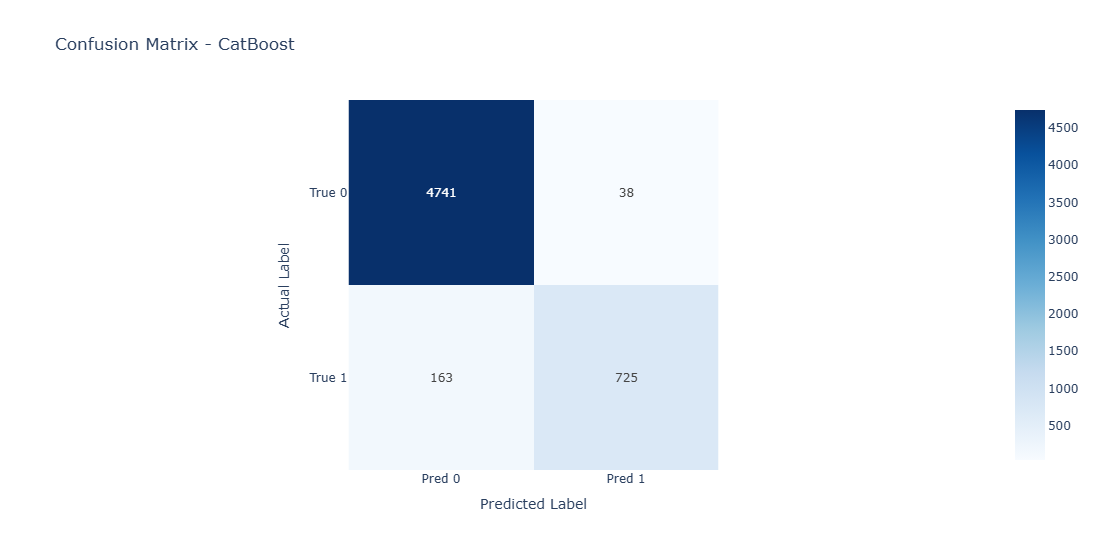

In [275]:
#Confusion matrix plot CatBoost
y_pred_cat = cat_metrics["y_pred"]
# print("CatBoost classification report:\n", classification_report(y_test, y_pred_cat))

#Converting dataframe for Plotly
cm_df = pd.DataFrame(
    cm2,
    index=[f"True {i}" for i in range(len(cm2))],
    columns=[f"Pred {i}" for i in range(len(cm2))]
)
fig = px.imshow(
    cm_df,
    text_auto=True,
    color_continuous_scale="Blues",
    title="Confusion Matrix - CatBoost"
)
fig.update_layout(
    width=650,
    height=550,
    xaxis_title="Predicted Label",
    yaxis_title="Actual Label",
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig.show()

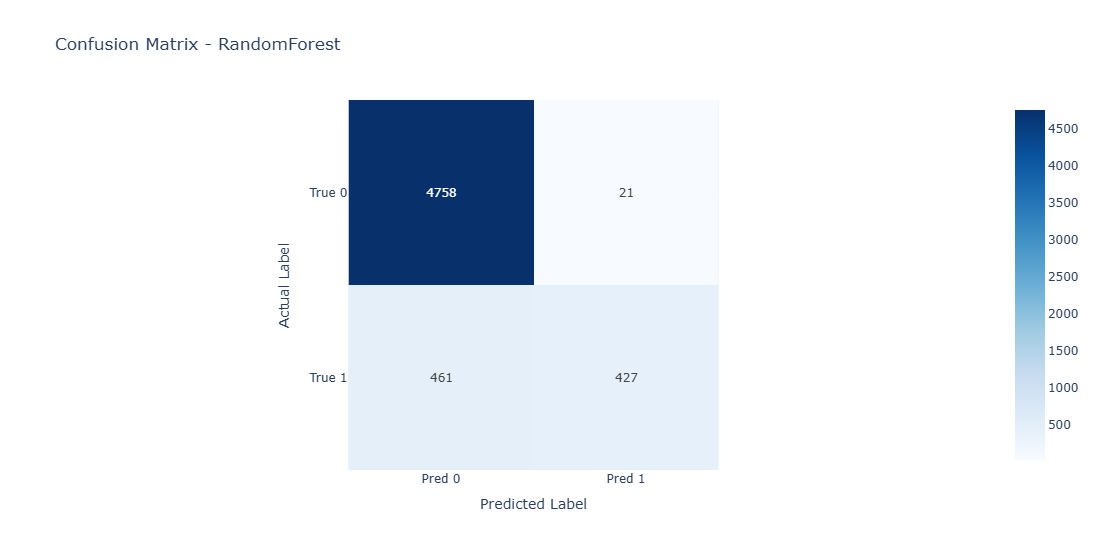

In [276]:
#confusion matrices for RandomForest predictions
y_pred_rf = rf_metrics["y_pred"]
# print("RandomForest classification report:\n", classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
fig = px.imshow(pd.DataFrame(cm_rf, index=[f"True {i}" for i in range(len(cm_rf))],
                             columns=[f"Pred {i}" for i in range(len(cm_rf))]),
            text_auto=True, color_continuous_scale="Blues", title="Confusion Matrix - RandomForest")
fig.update_layout(width=650, height=550, xaxis_title="Predicted Label", yaxis_title="Actual Label")
fig.show()

In [225]:
#Build feature names used by ColumnTransformer
feature_names = [] #numeric names
feature_names.extend(numeric_features)

try:
    tfidf_vec = preproc_rf.named_transformers_['txt'] #tfidf names
    tfidf_names = tfidf_vec.get_feature_names_out().tolist()
except Exception:
    try:
        tfidf_names = preproc_rf.named_transformers_['txt'].get_feature_names().tolist()
    except Exception:
        tfidf_names = [f"tfidf_{i}" for i in range(preproc_rf.transform(X_train).shape[1] - len(numeric_features) - len(categorical_features))]
feature_names.extend(tfidf_names)

#one-hot names
try:
    ohe = preproc_rf.named_transformers_['cat']
    ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(ohe_names)
except Exception:
    # fallback: placeholders for one-hot columns
    feature_names.extend([f"cat_ohe_{i}" for i in range(len(categorical_features))])
print("Total feature count (constructed):", len(feature_names))

transformed_shape = X_train_rf.shape[1] # check lengths mismatch 
if len(feature_names) != transformed_shape:
    print("WARNING: feature_names length", len(feature_names), "!= transformed shape", transformed_shape)

Total feature count (constructed): 11233


In [226]:
#RF importances and top features
importances = rf.feature_importances_
#ensure the importances length matches feature_names if not will map to indices
if len(importances) == len(feature_names):
    feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
else:
    feat_imp = pd.DataFrame({"Feature": [f"f_{i}" for i in range(len(importances))], "Importance": importances})

#Sort the features from most important to least important.
feat_imp = feat_imp.sort_values("Importance", ascending=False).reset_index(drop=True)
top_feat = feat_imp.head(30) #Select only the top 30 most important features
#plot bar chart 
fig = px.bar(
    top_feat[::-1], #reverse the order so the biggest bar is at the top
    x="Importance", 
    y="Feature",
    orientation="h",
    title="Top 30 Important Features : ",
    width=900,
    height=900
)
fig.show()

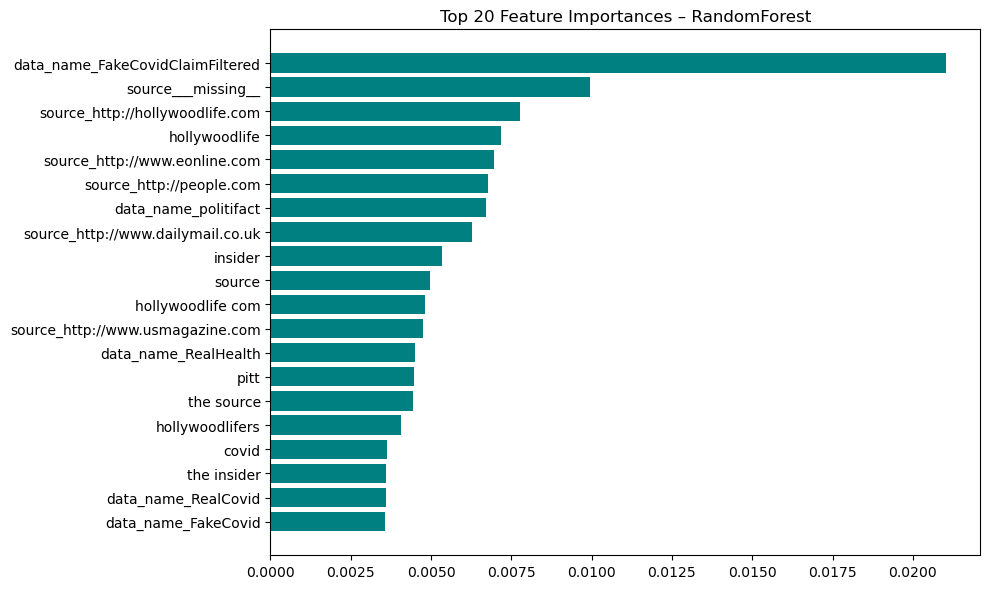

In [227]:
#feature importance 
# Ensure importances match feature names
importances = rf.feature_importances_
n_feat = len(importances)

if len(feature_names) != n_feat:
    print("Warning: feature_names length mismatch, using generic names.")
    feature_names_used = [f"f_{i}" for i in range(n_feat)]
else:
    feature_names_used = feature_names

df_imp = pd.DataFrame({
    "feature": feature_names_used,
    "importance": importances
}).sort_values("importance", ascending=False).head(20)

#Bar plot
plt.figure(figsize=(10,6))
plt.barh(df_imp["feature"], df_imp["importance"], color="teal")
plt.title("Top 20 Feature Importances – RandomForest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


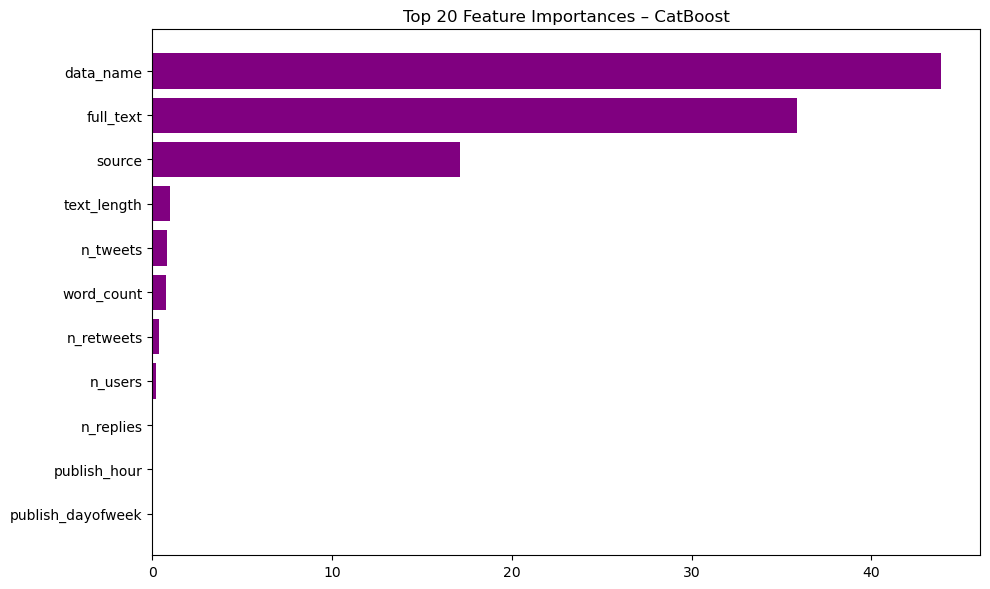

In [228]:
#Top 20 Feature Importances – CatBoost
cat_importances = model.get_feature_importance(train_pool)
cat_feat_names  = train_data.columns.tolist()  # names used in Pool

df_cat_imp = pd.DataFrame({
    "feature": cat_feat_names,
    "importance": cat_importances
}).sort_values("importance", ascending=False)

# Plot top 20 bar chart
plt.figure(figsize=(10,6))
plt.barh(df_cat_imp.head(20)["feature"], df_cat_imp.head(20)["importance"], color="purple")
plt.title("Top 20 Feature Importances – CatBoost")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [286]:
pool_features = [*categorical_features, *numeric_features, 'full_text']

#Work on copies to avoid accidental modification of original frames
train_data = X_train[pool_features].copy()
test_data  = X_test[pool_features].copy()

#clean categorical columns convert NaN then string token and cast to str
CAT_MISSING_TOKEN = "__missing__"

for c in categorical_features:
    if c in train_data.columns:
        train_data[c] = train_data[c].fillna(CAT_MISSING_TOKEN).astype(str)
        test_data[c]  = test_data[c].fillna(CAT_MISSING_TOKEN).astype(str)
    else:
        # if column missing, create it as missing string 
        train_data[c] = CAT_MISSING_TOKEN
        test_data[c]  = CAT_MISSING_TOKEN

#clean numeric columns fill NaN with median
for c in numeric_features:
    if c in train_data.columns:
        train_med = pd.to_numeric(train_data[c], errors='coerce').median()
        if np.isnan(train_med):
            train_med = 0.0
        train_data[c] = pd.to_numeric(train_data[c], errors='coerce').fillna(train_med)
        test_data[c]  = pd.to_numeric(test_data[c], errors='coerce').fillna(train_med)
    else:
        train_data[c] = 0.0
        test_data[c]  = 0.0

In [287]:
#clean text columns
if 'full_text' in train_data.columns:
    train_data['full_text'] = train_data['full_text'].fillna('').astype(str)
    test_data['full_text']  = test_data['full_text'].fillna('').astype(str)
else:
    train_data['full_text'] = ''
    test_data['full_text']  = ''

In [288]:
#Build Pools giving categorical- only column names and feature names 
train_pool = Pool(data=train_data, label=y_train, 
                  cat_features=categorical_features, text_features=['full_text'])
test_pool  = Pool(data=test_data, label=y_test, 
                  cat_features=categorical_features, text_features=['full_text'])

# Train CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100
)

In [289]:
# Fit with eval set for monitoring; this prints progress but does not save files
model.fit(train_pool, eval_set=test_pool, use_best_model=False, verbose=100)

# Evaluate
y_pred = model.predict(test_pool)
# print("\n=== Classification report (CatBoost Pool) ===")
# print(classification_report(y_test, y_pred))

0:	learn: 0.6564981	test: 0.6568932	best: 0.6568932 (0)	total: 132ms	remaining: 1m 5s
100:	learn: 0.1013928	test: 0.0907079	best: 0.0907079 (100)	total: 12.2s	remaining: 48s
200:	learn: 0.0873611	test: 0.0859758	best: 0.0859758 (200)	total: 23.6s	remaining: 35s
300:	learn: 0.0772038	test: 0.0838130	best: 0.0838121 (298)	total: 35.2s	remaining: 23.3s
400:	learn: 0.0685683	test: 0.0824428	best: 0.0824012 (397)	total: 47.7s	remaining: 11.8s
499:	learn: 0.0613051	test: 0.0814677	best: 0.0814585 (497)	total: 59.5s	remaining: 0us

bestTest = 0.08145850471
bestIteration = 497



Sample prepared for SHAP: shape (80, 11)
Computing SHAP values (passing explicit Pool)


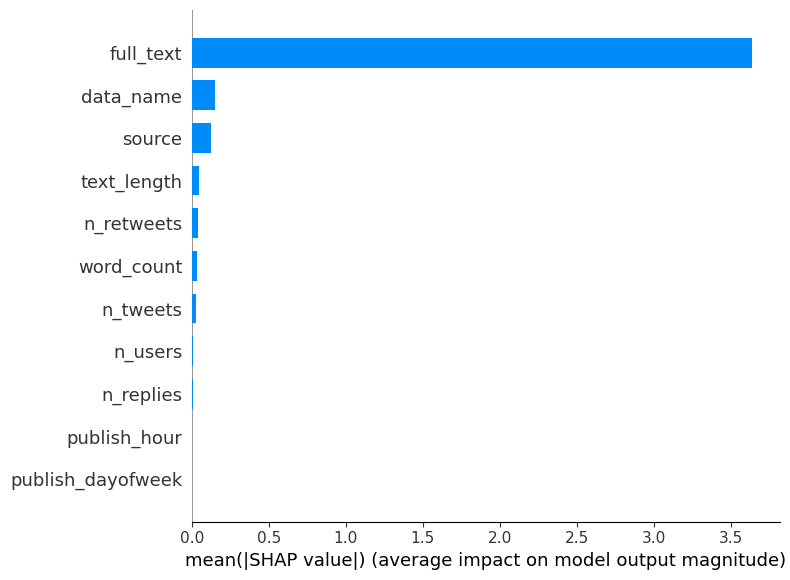

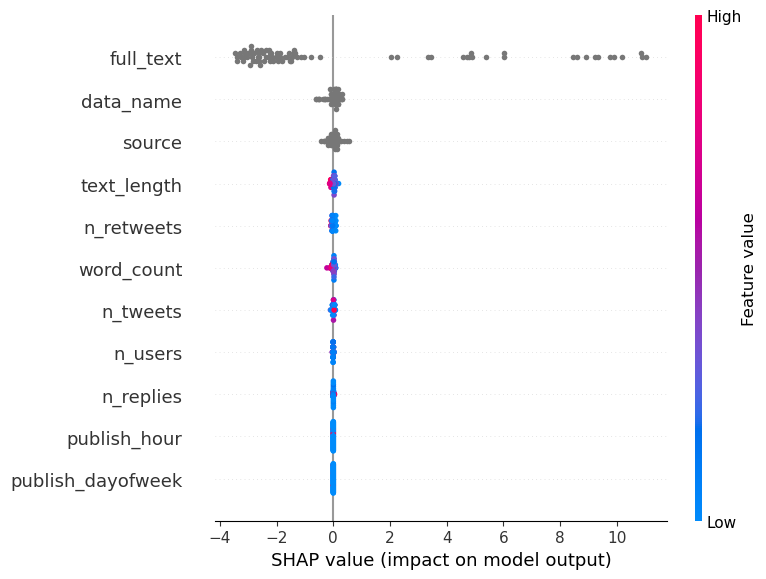

In [291]:
#selection of which data for shap[
feature_cols = categorical_features + numeric_features + ['full_text']  #text column name

X_for_shap = test_data[feature_cols].copy()   #train_data- feature_cols

#quick sample
TEST_SAMPLE = min(80, len(X_for_shap))
X_sample = X_for_shap.sample(n=TEST_SAMPLE, random_state=24).reset_index(drop=True)

for c in categorical_features:
    X_sample[c] = X_sample[c].fillna("__missing__").astype(str) #double checking categorical columns are strings
for c in numeric_features:
    X_sample[c] = pd.to_numeric(X_sample[c], errors='coerce').fillna(0.0) #double checking numeric are numeric
if 'full_text' in X_sample.columns:
    X_sample['full_text'] = X_sample['full_text'].fillna('').astype(str) #double checking text is string

print("Sample prepared for SHAP: shape", X_sample.shape)

#creating an explicit CatBoost Pool with categorical and text features specified by NAME
pool_for_shap = Pool(data=X_sample, label=None,
                     cat_features=categorical_features,
                     text_features=['full_text'] if 'full_text' in X_sample.columns else None)

#TreeExplainer in CatBoost mode
explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent")

#pass shap to shap_values
print("Computing SHAP values (passing explicit Pool)")
shap_values = explainer.shap_values(pool_for_shap)

#handling multiclass
is_multi = isinstance(shap_values, list) and len(shap_values) > 1
if is_multi:
    mean_abs = [np.mean(np.abs(v)) for v in shap_values]
    class_idx = int(np.argmax(mean_abs))
    shap_to_plot = shap_values[class_idx]
    expected_value = explainer.expected_value[class_idx] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    shap_to_plot = shap_values
    expected_value = explainer.expected_value

#conversion of parse
if hasattr(shap_to_plot, "toarray"):
    shap_to_plot = shap_to_plot.toarray()

#quick plots
TOP_K_FEATURES = 12
plt.figure(); shap.summary_plot(shap_to_plot, X_sample, plot_type="bar", max_display=TOP_K_FEATURES, show=True)
plt.figure(); shap.summary_plot(shap_to_plot, X_sample, max_display=TOP_K_FEATURES, show=True)